# SEM Microstructure Semantic Segmentation

**UNet (ResNet-34 Encoder) · PyTorch · Transfer Learning · Multi-class Pixel Segmentation**


### Default python libraries

In [1]:
import sys
import numpy as np
from PIL import Image
import os, random, glob
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt

#--- Default pytroch libraries---
import torch 
import torch.nn as nn
import torch.nn.functional as F 
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

import time 

### Modules required for this project

In [3]:
# adding parent directory in the search path
#import importlib

sys.path.append(os.path.abspath('..'))
import dataset, utils, model, train, evaluate, metrics

**Images and Maks directories**

In [4]:
mask_dir = Path('/Volumes/turing/AI_ML_Projects/sem_dataset/AugmentedMasks')
img_dir  =  Path('/Volumes/turing/AI_ML_Projects/sem_dataset/AugmentedImages')

**Quick inspetion script (unique values / colors)**

In [5]:
mfiles = os.listdir(mask_dir)
print("mask file: ",mfiles[0])
mask_path = Path(mask_dir,mfiles[0]) 

utils.maskinfo(mask_path)

mask file:  sem700_x0_y288_ElasticTransform.bmp
PIL mode: L
Shape: (512, 512) dtype: uint8
Unique label value: [1 2 3 4 5]
num unique: 5


### Dinctionary: masks ids

In [6]:
mask_ds = utils.mask_ids(mask_dir)

# view one element
#print(next(iter(mask_ds.items())))

## Train, test, val split procedure

- Train 300
- Val 50
- test 55

Applied to the group level. 

File name structure: base name up to 3rd underscore. Rest of it is augmentation label

**Leakage-safe splits(grouped)**

1. group files by  base key 
2. shuffle groups 
3. assign groups to train/val/test
4. produce file list


**Load image files and split**

In [7]:
filenames = os.listdir(img_dir)
splits, groups = dataset.make_grouped_split(filenames, n_train=300, n_val=50, n_test=55, seed=42)

In [8]:
# Sanity check 
def sanity_check_no_leaks(splits):
    inv = {}
    for split, files in splits.items():
        for f in files:
            k = dataset.base_key(f)
            if k in inv and inv[k] != split:
                raise RuntimeError(f"Leak: group {k} in {inv[k]} and {split}")
            inv[k] = split
    return True 
sanity_check_no_leaks(splits)

True

**train, val, test split len check**

In [9]:
len(splits['train']), len(splits['val']), len(splits['test'])

(297, 54, 54)

### Datasets and Dataloader ( with label remap)

- loads image/mask .bmp
- remaps mask IDs: 1..5 -> 0..4

returns: 

- image tensor: shape (1,512, 512) float32 in [0,1]
- maks tensor : shape(512,512) int64 with values {0..4}

show a sanility plot

sem1000_x0_y256_GridDistortion.bmp torch.Size([1, 512, 512]) torch.float32 torch.int64 unique:  tensor([0, 2, 3, 4])


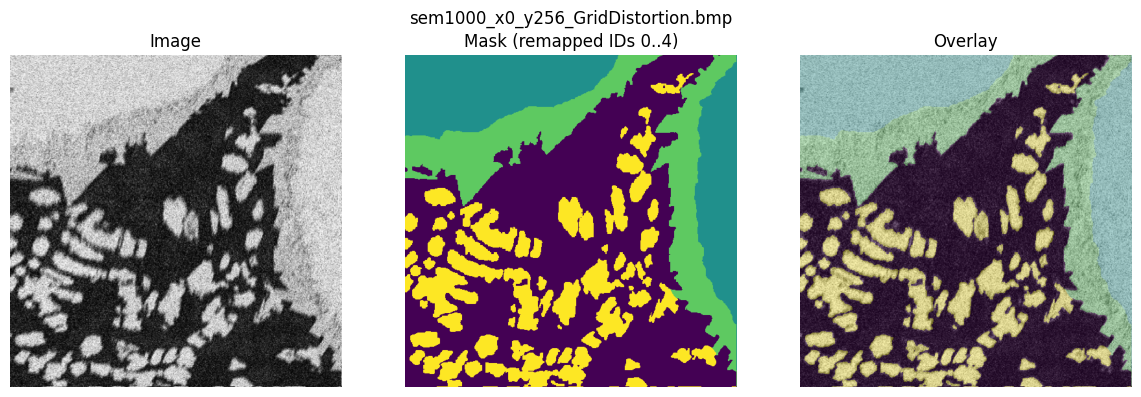

sem1000_x0_y256_HorizontalFlip.bmp torch.Size([1, 512, 512]) torch.float32 torch.int64 unique:  tensor([0, 2, 3, 4])


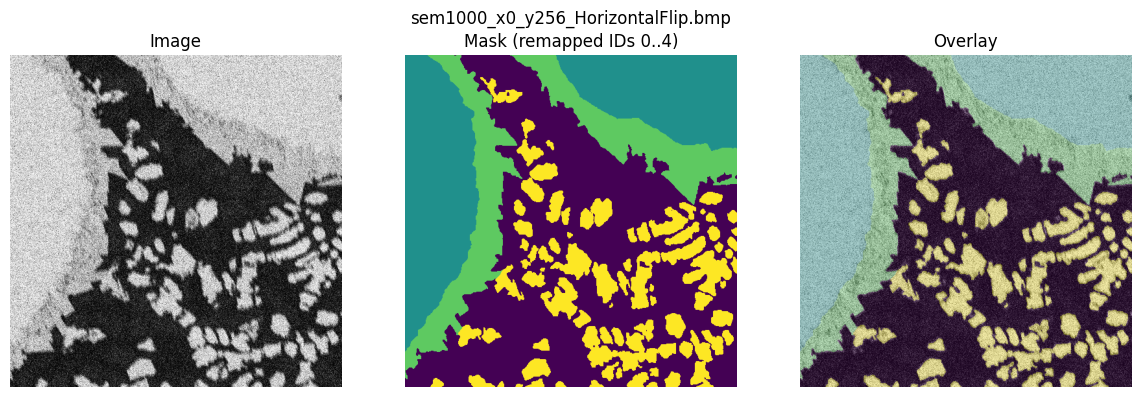

Batch imgs: torch.Size([4, 1, 512, 512]) torch.float32
Batch masks torch.Size([4, 512, 512]) torch.int64
Filenames: ('sem600_x768_y448_brightness_3.bmp', 'sem800_x768_y0_brightness_3.bmp', 'sem1000_x0_y0_contrast_3.bmp', 'sem700_x256_y256_HorizontalFlip.bmp')


In [10]:
train_files = splits['train']
val_files   = splits['val']

# Minimal test and plots

ds = dataset.SEMSegDataset(img_dir,mask_dir, train_files)
for i in range(min(2, len(ds))):
    img, msk, fname = ds[i]
    print(fname, img.shape, img.dtype, msk.dtype, "unique: ", torch.unique(msk))
    utils.show_sample(img, msk, title=fname)

# dataloadr sanity check
dl = DataLoader(ds, batch_size=4, shuffle=True, num_workers=0)
batch = next(iter(dl))
imgs, masks, fname = batch
print("Batch imgs:", imgs.shape, imgs.dtype)
print("Batch masks", masks.shape,masks.dtype )
print("Filenames:", fname)
    

**Check for class imbalance**

In [12]:
from tqdm import tqdm

NUM_CLASSES = 5

def compute_pixel_hist(filenames, masks_dir, remap_lut):
    hist = np.zeros(NUM_CLASSES, dtype=np.int64)
    total = 0

    for fname in tqdm(filenames, desc="Counting pixels"):
        m = np.array(Image.open(masks_dir / fname), dtype=np.uint8)
        m2 = remap_lut[m] # 0..4

        # safety check 
        if(m2 == 255).any():
            bad = np.unique(m[m2 == 255])
            raise ValueError(f"Unmapped labels in {fname}: {bad}")
        
        for c in range(NUM_CLASSES):
            hist[c] += np.sum(m2==c)
        total += m2.size

    frac = hist / total
    return hist, frac

train_hist, train_frac = compute_pixel_hist(train_files, mask_dir, dataset.REMAP)
val_hist, val_frac = compute_pixel_hist(val_files, mask_dir, dataset.REMAP)

print("Train pixel fractions:", train_frac)
print("Val pixel fractions:  ", val_frac)



Counting pixels: 100%|██████████| 54/54 [00:00<00:00, 1237.17it/s]

Train pixel fractions: [0.34296349 0.00052678 0.41297214 0.11211598 0.13142161]
Val pixel fractions:   [0.32117469 0.03471233 0.38850883 0.10331182 0.15229232]


### What’s happening

**Train distribution**

- class 0 (matrix): 34.3%

- class 1 (void): 0.053% ← extremely rare

- class 2 (carbide): 41.3%

- class 3 (dilution): 11.2%

- class 4: 13.1%


So in training, the model will almost never see void pixels. It can get a good loss by effectively ignoring class 1.


**Val distribution**

Void is 3.47% in validation — that’s ~66× more void than in training.

So the model is being evaluated on void much more than it was trained on. That’s why void IoU stays near zero: it’s a real distribution shift.

### Class weight calculation (with safe clipping)

In [13]:
import copy 
train_frac = copy.deepcopy(train_frac)

p = 0.05
# Inverse weighting 
W = (1.0 / (train_frac + 1e-8)) ** p 
# normalize to mean = 1

W = W / W.mean()
#W = W / W.min()


# clip so void doesnot dominate training 

class_weight_list = (np.clip(W, 0.25, 6.0)).tolist()
weights_t = torch.tensor(W, dtype=torch.float32, device=train.get_device())

print(f"Weigth: {W}")
print(class_weight_list)
print("class weight tensor", weights_t, weights_t.shape)


Weigth: [0.91242027 1.26146629 0.90398512 0.96488141 0.95724692]
[0.9124202664993306, 1.261466285467339, 0.9039851166336204, 0.9648814124729173, 0.9572469189267926]
class weight tensor tensor([0.9124, 1.2615, 0.9040, 0.9649, 0.9572], device='mps:0') torch.Size([5])


## Train using UNet built from scratch 

In [13]:
# Model checkpoint path 
def model_path(base_name):
     extension_name = input("Write the model name for saving")
     if base_name is None:
          raise RuntimeError("Model saving base path and model name needed")
     save_dir = Path(base_name)
     save_dir.mkdir(parents=True, exist_ok=True)
     
     model_path = './' + base_name + '/' + extension_name + '_best_unet' + '.' + 'pth'
     return str(model_path)

BEST_PATH = model_path('Unet_best_model')

In [14]:
BEST_PATH

'./Unet_best_model/ScratchUNet_best_unet.pth'

**get scratch built model**

In [15]:
NUM_CLASSES = 5
BATCH_SIZE  = 4
EPOCHS      = 20
LR          = 1e-3
WEIGHT_DECAY = 1e-5

device = train.get_device()

# -- model --
scratch_model = model.UNetScratch(in_channels=1, num_classes=NUM_CLASSES).to(device)

# -- datasets --
train_ds = dataset.SEMSegDataset(img_dir, mask_dir, train_files)
val_ds   = dataset.SEMSegDataset(img_dir, mask_dir, val_files)

# -- dataloaders --
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# -- optimizer & scheduler --
optimizer = train.make_optimizer(scratch_model, lr=LR)
scheduler, scheduler_is_plateau = train.build_scheduler(optimizer, scheduler_type="plateau", epochs=EPOCHS)

best_miou = -1.0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()

    train_loss = train.train_one_epoch(scratch_model, train_dl, optimizer=optimizer, device=device, class_weight=weights_t)
    val_loss, mean_iou, mean_dice, iou_pc, dice_pc = train.evaluate(scratch_model, val_dl, device=device, class_weight=weights_t, num_classes=NUM_CLASSES)

    # -- scheduler step --
    if scheduler is not None:
        scheduler.step(val_loss) if scheduler_is_plateau else scheduler.step()

    dt     = time.time() - t0
    lr_now = optimizer.param_groups[0]["lr"]

    print(f"\nEpoch {epoch:02d}/{EPOCHS}  (lr={lr_now:.2e}, {dt:.1f}s)")
    print(f"  train_loss={train_loss:.4f}")
    print(f"  val:  loss={val_loss:.4f}  meanIoU={mean_iou:.4f}  meanDice={mean_dice:.4f}")
    print(f"  val IoU  per class:  {iou_pc.numpy()}")
    print(f"  val Dice per class:  {dice_pc.numpy()}")

    # -- save best checkpoint --
    if mean_iou > best_miou:
        best_miou = mean_iou
        torch.save(
            {
                "epoch":           epoch,
                "model_state":     scratch_model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "best_miou":       best_miou,
            },
            BEST_PATH,
        )
        print(f"  Saved best checkpoint → {BEST_PATH}  (meanIoU={best_miou:.4f})")


Epoch 01/20  (lr=1.00e-03, 41.6s)
  train_loss=0.5334
  val:  loss=0.3876  meanIoU=0.5967  meanDice=0.6761
  val IoU  per class:  [8.2003760e-01 2.0350848e-12 9.3133295e-01 5.1236665e-01 7.1993846e-01]
  val Dice per class:  [9.0112162e-01 2.0350848e-12 9.6444577e-01 6.7756933e-01 8.3716768e-01]
  Saved best checkpoint → ./Unet_best_model/ScratchUNet_best_unet.pth  (meanIoU=0.5967)

Epoch 02/20  (lr=1.00e-03, 41.0s)
  train_loss=0.3032
  val:  loss=0.4446  meanIoU=0.6167  meanDice=0.6918
  val IoU  per class:  [8.1803757e-01 2.0350848e-12 9.2384642e-01 5.7871175e-01 7.6310438e-01]
  val Dice per class:  [8.9991271e-01 2.0350848e-12 9.6041596e-01 7.3314428e-01 8.6563718e-01]
  Saved best checkpoint → ./Unet_best_model/ScratchUNet_best_unet.pth  (meanIoU=0.6167)

Epoch 03/20  (lr=1.00e-03, 40.8s)
  train_loss=0.2117
  val:  loss=0.2933  meanIoU=0.6673  meanDice=0.7258
  val IoU  per class:  [8.3356702e-01 2.0350848e-12 9.5575744e-01 7.2077072e-01 8.2633555e-01]
  val Dice per class:  [9

## Pretrained model ( resnet34 encoder)

In [ ]:

cfg = model.PretrainedUNetConfig(encoder_name="resnet34", encoder_weights="imagenet", in_channels=1, num_classes=NUM_CLASSES)
pretrained_model = model.build_smp_unet(cfg).to(device)

In [17]:
history, ckpt_path = train.train_model(
    model          = pretrained_model,
    train_dl       = train_dl,
    val_dl         = val_dl,
    device         = device,
    class_weight   = weights_t,
    num_classes    = NUM_CLASSES,
    num_epochs     = EPOCHS,
    freeze_epochs  = 4,          # freeze encoder for first 4 epochs
    lr_frozen      = 1e-3,
    lr_unfrozen    = 1e-4,
    scheduler_type = "plateau",
    monitor        = "miou",
)

Epoch 01/20  lr=1.00e-03 | train_loss=0.4241  val_loss=0.3450 | mIoU=0.634  mDice=0.704  ← best
Epoch 02/20  lr=1.00e-03 | train_loss=0.1986  val_loss=0.2857 | mIoU=0.679  mDice=0.733  ← best
Epoch 03/20  lr=1.00e-03 | train_loss=0.1600  val_loss=0.3198 | mIoU=0.674  mDice=0.730
Epoch 04/20  lr=1.00e-03 | train_loss=0.1382  val_loss=0.2480 | mIoU=0.694  mDice=0.742  ← best
[Epoch 5] Unfreezing encoder, switching to lr=1.00e-04
Epoch 05/20  lr=1.00e-04 | train_loss=0.1172  val_loss=0.2345 | mIoU=0.699  mDice=0.745  ← best
Epoch 06/20  lr=1.00e-04 | train_loss=0.1107  val_loss=0.2485 | mIoU=0.699  mDice=0.745  ← best
Epoch 07/20  lr=1.00e-04 | train_loss=0.1009  val_loss=0.2299 | mIoU=0.703  mDice=0.747  ← best
Epoch 08/20  lr=1.00e-04 | train_loss=0.0923  val_loss=0.1860 | mIoU=0.696  mDice=0.743
Epoch 09/20  lr=1.00e-04 | train_loss=0.0911  val_loss=0.2224 | mIoU=0.707  mDice=0.750  ← best
Epoch 10/20  lr=1.00e-04 | train_loss=0.0819  val_loss=0.1302 | mIoU=0.863  mDice=0.924  ← best
E

## Test and evaluate

In [11]:
import evaluate as eval_module
import train, model


device = train.get_device()
#-- test data --
test_files = splits['test']
test_ds = dataset.SEMSegDataset(img_dir, mask_dir, test_files)
test_dl = DataLoader(test_ds, batch_size=4, shuffle=False,  num_workers=0)
best_ckpt = "./checkpoints/best_model.pth"


### Test

In [ ]:

# Rebuild the same architecture
NUM_CLASSES = 5
cfg = model.PretrainedUNetConfig(encoder_name="resnet34", encoder_weights="imagenet", in_channels=1, num_classes=NUM_CLASSES)
trained_model = model.build_smp_unet(cfg).to(device)
#trained_model = model.UNetScratch(in_channels=1, num_classes=NUM_CLASSES)

# Run test_model — loads checkpoint + evaluates in one call
stats = eval_module.test(
    model           = trained_model,
    test_loader     = test_dl,
    device          = train.get_device(),
    num_classes     = NUM_CLASSES,
    ckpt_path       = best_ckpt,   # saved .pth
)

Loaded checkpoint  epoch=12  best_miou=0.8758167028427124

TEST RESULTS
  mIoU=0.8878  mDice=0.9388
  IoU  per class:  [0.9389 0.7525 0.976  0.891  0.8805]
  Dice per class:  [0.9685 0.8588 0.9878 0.9423 0.9365]


### Confusion matrix and batch level score

In [15]:
import seaborn as sns

from metrics import hard_metrics_from_logits, confusion_matrix, confusion_percent, boundary_f1_per_class
import evaluate as eval_module

# 1. Rebuild architecture
cfg = model.PretrainedUNetConfig(encoder_name="resnet34", encoder_weights="imagenet", in_channels=1, num_classes=NUM_CLASSES)
trained_model = model.build_smp_unet(cfg).to(device)

# 2. Load the saved weights into it
ckpt = eval_module.load_checkpoint(best_ckpt, trained_model)
trained_model.eval()

# 3. Now you can get logits and call metrics
cm_global = torch.zeros((NUM_CLASSES, NUM_CLASSES), dtype=torch.int64)

batch_scores = []

with torch.no_grad():
    for batch_idx, (imgs, masks, fnames) in enumerate(test_dl):
        imgs  = imgs.to(device)
        masks = masks.to(device)

        logits = trained_model(imgs)
        m      = hard_metrics_from_logits(logits, masks, num_classes=NUM_CLASSES)
        preds  = m["preds"]

        cm_global += confusion_matrix(preds.cpu(), masks.cpu(), num_classes=NUM_CLASSES)
        bf1 = boundary_f1_per_class(preds.cpu(), masks.cpu(), num_classes=NUM_CLASSES, radius=2)
        batch_scores.append(
            {"batch_idx": batch_idx,
             "fnames"   : fnames,
             "mIoU"     : m['mean_iou'],
             "mDice"    : m['mean_dice'],
             "mbf1"     : float(bf1.mean())           
             }
        )
        print(f"  mIoU={m['mean_iou']:.4f}  mDice={m['mean_dice']:.4f}  mBF1={bf1.mean():.4f}")
# Sort by MIoU
batch_scores.sort(key=lambda x : x['mIoU'])
worst = batch_scores[0]
best = batch_scores[-1]

# 4. Global confusion matrix
print("\nGlobal Confusion Matrix (%):")
print(confusion_percent(cm_global).numpy().round(2))

print(f"Best  batch {best['batch_idx']:02d}  mIoU={best['mIoU']:.4f}  files={best['fnames']}")
print(f"Worst batch {worst['batch_idx']:02d}  mIoU={worst['mIoU']:.4f}  files={worst['fnames']}")

  mIoU=0.9456  mDice=0.9715  mBF1=0.7319
  mIoU=0.9507  mDice=0.9743  mBF1=0.7500
  mIoU=0.7446  mDice=0.7711  mBF1=0.7203
  mIoU=0.7390  mDice=0.7681  mBF1=0.6990
  mIoU=0.8800  mDice=0.9353  mBF1=0.7260
  mIoU=0.8362  mDice=0.9089  mBF1=0.7307
  mIoU=0.8812  mDice=0.9359  mBF1=0.7675
  mIoU=0.9494  mDice=0.9737  mBF1=0.7494
  mIoU=0.9577  mDice=0.9782  mBF1=0.7730
  mIoU=0.9348  mDice=0.9655  mBF1=0.7342
  mIoU=0.9347  mDice=0.9654  mBF1=0.7357
  mIoU=0.9395  mDice=0.9683  mBF1=0.7215
  mIoU=0.7348  mDice=0.7657  mBF1=0.7135
  mIoU=0.7229  mDice=0.7591  mBF1=0.6783

Global Confusion Matrix (%):
[[9.726e+01 1.000e-02 0.000e+00 7.600e-01 1.970e+00]
 [2.230e+01 7.538e+01 1.000e-02 7.000e-02 2.250e+00]
 [0.000e+00 0.000e+00 9.886e+01 1.140e+00 0.000e+00]
 [1.910e+00 0.000e+00 2.780e+00 9.463e+01 6.800e-01]
 [4.840e+00 0.000e+00 2.000e-02 1.870e+00 9.326e+01]]
Best  batch 08  mIoU=0.9577  files=('sem700_x256_y288_contrast_4.bmp', 'sem700_x256_y288_brightness_3.bmp', 'sem700_x256_y288_brig

### File level score

In [16]:
batch_scores = []

trained_model.eval()
with torch.no_grad():
    for batch_idx, (imgs, masks, fnames) in enumerate(test_dl):
        imgs  = imgs.to(device)
        masks = masks.to(device)

        logits = trained_model(imgs)

        # score each image individually
        for i in range(imgs.shape[0]):
            logit_i = logits[i].unsqueeze(0)   # (1,C,H,W)
            mask_i  = masks[i].unsqueeze(0)    # (1,H,W)

            m   = hard_metrics_from_logits(logit_i, mask_i, num_classes=NUM_CLASSES)
            bf1 = boundary_f1_per_class(m["preds"].cpu(), mask_i.cpu(), num_classes=NUM_CLASSES, radius=2)

            batch_scores.append({
                "fname": fnames[i],
                "miou":  m["mean_iou"],
                "mdice": m["mean_dice"],
                "mbf1":  float(bf1.mean()),
            })

# sort by mIoU per image
batch_scores.sort(key=lambda x: x["miou"])

worst = batch_scores[0]
best  = batch_scores[-1]

print(f"Best  image: {best['fname']}   mIoU={best['miou']:.4f}  mDice={best['mdice']:.4f}  mBF1={best['mbf1']:.4f}")
print(f"Worst image: {worst['fname']}  mIoU={worst['miou']:.4f}  mDice={worst['mdice']:.4f}  mBF1={worst['mbf1']:.4f}")

Best  image: sem700_x256_y288_contrast_3.bmp   mIoU=0.9612  mDice=0.9800  mBF1=0.7873
Worst image: sem800_x0_y256_GridDistortion.bmp  mIoU=0.7099  mDice=0.7517  mBF1=0.6443


In [24]:
best['miou']

0.9612435102462769

In [22]:
best_image = Path(img_dir, best['fname'])
best_mask = Path(mask_dir, best['fname'])
print(best_mask)

/Volumes/turing/AI_ML_Projects/sem_dataset/AugmentedMasks/sem700_x256_y288_contrast_3.bmp


### Plot : 

In [28]:
    
def show_img(image, msk, title=None):
    img = Image.open(image).convert("L")
    mask = Image.open(msk).convert("L")

    plt.figure(figsize=(12,4))
    plt.subplot(1,3,1)
    plt.title("Image")
    plt.imshow(img, cmap="gray")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title("Mask (remapped IDs 0..4)")
    plt.imshow(mask)
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.title("Overlay")
    plt.imshow(img, cmap='gray')
    plt.imshow(mask, alpha=0.35)
    plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:

import seaborn as sns



def normalize_confusion_matrix(cm):
    cm = cm.numpy()
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_percent = np.divide(cm, row_sums, where=row_sums!=0) * 100
    return cm_percent



CLASS_NAMES = ["Matrix", "Carbide", "Void", "Reprecip", "Dilution"]




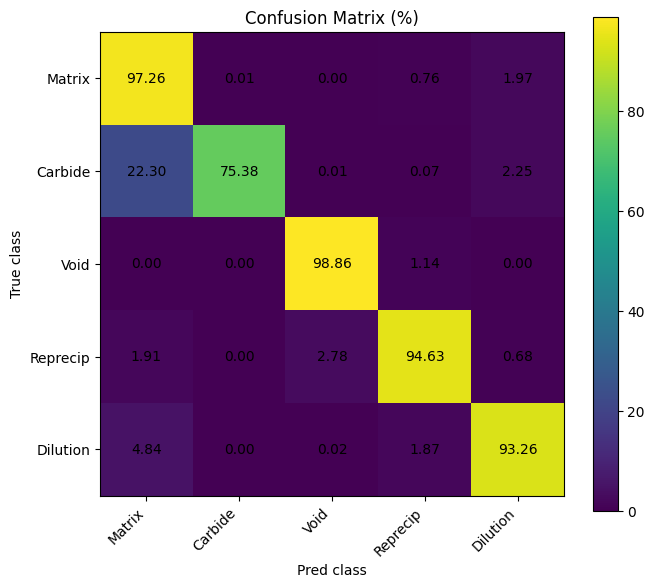

In [40]:
cm_percent = normalize_confusion_matrix(cm_global)
utils.plot_confusion_matrix_percent(cm_percent, class_names=CLASS_NAMES)

### Best and worst performing segmented images 

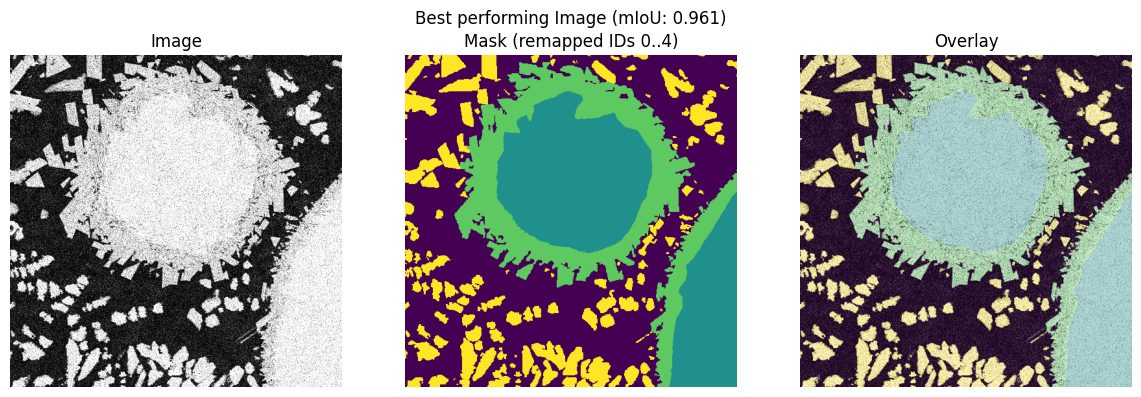

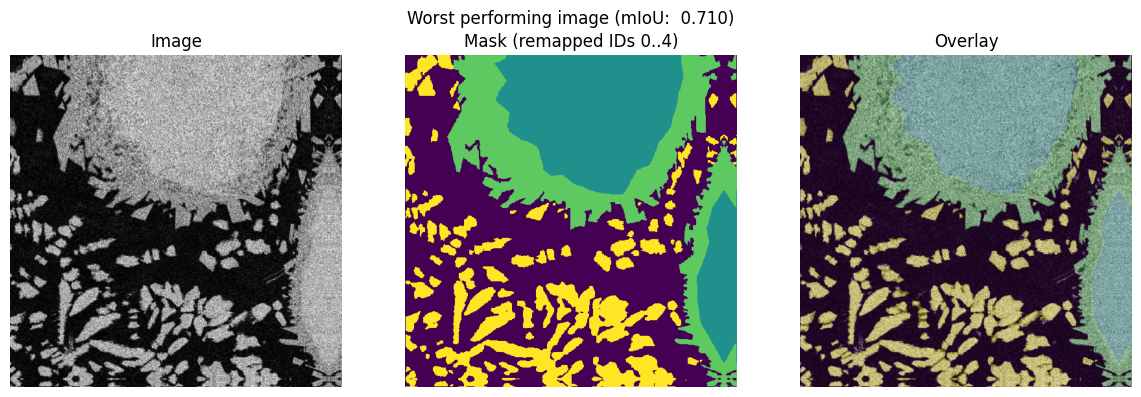

In [33]:
show_img(best_image,best_mask, title=f'Best performing Image (mIoU: {best['miou']:.3f})')
show_img(Path(img_dir,worst['fname']),Path(mask_dir,worst['fname']), title= f"Worst performing image (mIoU: {worst['miou']: .3f})")

## Conclusion

# Conclusion

This project developed and evaluated a deep learning pipeline for multi-class semantic segmentation of Scanning Electron Microscopy (SEM) images, targeting five microstructural phases: Matrix, Carbide, Void, Reprecipitate, and Dilution zone. A UNet architecture with a pretrained ResNet-34 encoder was trained on an augmented dataset and evaluated on a held-out test set of 54 images.

## Performance Summary

The model demonstrated strong segmentation performance across the test set. Evaluated at the image level to avoid batch-size bias, the model achieved the following aggregate results:

| Metric        | Mean  | Std   | Min   | Max   |
|---------------|-------|-------|-------|-------|
| mIoU          | 0.872 | 0.088 | 0.723 | 0.958 |
| mDice         | 0.912 | 0.079 | 0.759 | 0.978 |
| mBF1          | 0.728 | 0.027 | 0.678 | 0.773 |

The mean Intersection over Union (mIoU) of **0.872** and mean Dice score of **0.912** confirm that the model produces highly accurate pixel-wise segmentation masks across the majority of test images. The mean Boundary F1 (mBF1) of **0.728** reflects moderate precision at class boundaries, which is expected given the fine structural detail and low contrast between adjacent phases in SEM imagery.

## Per-Class Analysis

The pixel-wise confusion matrix revealed notable differences in per-class difficulty:

| Class        | Correctly Classified (%) | Primary Confusion         |
|--------------|--------------------------|---------------------------|
| Matrix       | 97.3                     | Dilution (1.97%)          |
| Carbide      | 75.4                     | Matrix (22.3%)            |
| Void         | 98.9                     | Reprecipitate (1.14%)     |
| Reprecipitate| 94.6                     | Void (2.78%)              |
| Dilution     | 93.3                     | Matrix (4.84%)            |

The Void and Matrix classes achieved near-perfect classification rates, likely due to their visually distinct appearance in SEM images. The Carbide class was the most challenging, with 22.3% of Carbide pixels misclassified as Matrix. This is consistent with the visual similarity between fine carbide precipitates and the surrounding matrix at certain imaging conditions, and is reflected in the lowest per-class IoU observed during evaluation.

## Best and Worst Performing Images

The best performing image group (mIoU = 0.958) consisted of contrast- and brightness-augmented variants of the same base image (`sem700_x256_y288`), suggesting the model handles photometric variation well. The lowest scoring images (`sem800_x0_y256` with VerticalFlip and GridDistortion augmentations) achieved mIoU = 0.723, indicating that geometric distortions — particularly grid distortion — remain a challenge for precise boundary delineation, consistent with the relatively lower mBF1 scores observed overall.

## Limitations and Future Work

Despite strong overall performance, several limitations remain. The Carbide class presents a persistent source of confusion with the Matrix class, which could be addressed through targeted strategies such as increased augmentation for underrepresented classes, harder negative mining, or incorporating higher resolution inputs to preserve fine-grained carbide morphology. The mBF1 scores, while acceptable, suggest that boundary precision could be improved through boundary-aware loss functions or post-processing refinement such as conditional random fields (CRF).

Future work could explore applying the pretrained pipeline to new SEM imaging conditions, extending the class set to additional microstructural phases, and deploying the model as a real-time inference service — for which the FastAPI and Docker integration planned as the next stage of this project provides a natural foundation.

## Acknowledgement 

SEM microstructure dataset used in this work was obtained from the publicly available Zenodo repository.

Safdar, M. (2025). Scanning Electron Microscopy (SEM) Dataset of Additively Manufactured Ni-WC Metal Matrix Composites for Semantic Segmentation (Version 1) [Data set]. 
Zenodo. https://doi.org/10.5281/zenodo.17315241

All credit for dataset creation and annotation belongs to the original contributors.